# Abstract:

They make the surface “self-affine” by generating it so that the typical height difference between two points gets larger as the points are farther apart, following a simple power-law relationship controlled by the Hurst exponent**. Then they convert the 3D surface into one JRC value by **taking many straight-line slices (profiles) in the flow direction, computing a JRC for each slice from its average slope roughness, and averaging those JRC values.


Xue et al. (2022) model the fracture surface as a random height field
$$
a(x,y),
$$
defined on a planar domain $(x,y)$. The surface is assumed to be self-affine. For two points separated by a vector $(\Delta x,\Delta y)$, the height increment is defined as
$$
h(x,y;\Delta x,\Delta y)
=
a(x+\Delta x,\,y+\Delta y) - a(x,\,y).
$$
The self-affine assumption is expressed through the statistics of these increments. First, the increments have zero mean,
$$
\Big\langle a(x+\Delta x,\,y+\Delta y) - a(x,\,y) \Big\rangle = 0,
$$
so that the surface exhibits no systematic upward or downward trend in a statistical sense. Second, the variance of the increments depends on the separation distance only and follows a power-law scaling. Let
$$
r = \sqrt{(\Delta x)^2 + (\Delta y)^2}
$$
denote the separation distance. The variance of the height increments at distance $r$ is defined by
$$
\sigma^2(r)
=
\Big\langle 
\big[a(x+\Delta x,\,y+\Delta y) - a(x,\,y)\big]^2 
\Big\rangle.
$$
For a self-affine surface with Hurst exponent $H$, Xue et al. assume
$$
\sigma^2(r) = r^{2H}\,\sigma^2(1),
$$
or, equivalently,
$$
\sigma(r) \propto r^{H},
$$
where $\sigma^2(1)$ is the variance at unit separation. Thus, the typical amplitude of the height difference between two points grows with distance $r$ as a power law with exponent $H$. In practice, a modified Successive Random Addition (SRA) algorithm is employed to construct a discrete field $a_{ij} = a(x_i,y_j)$ whose increments are approximately Gaussian, have zero mean, and satisfy the variance scaling law above.

To quantify the roughness of the generated three-dimensional fracture surface in terms of the traditional Joint Roughness Coefficient (JRC), Xue et al. use the slope-based parameter $Z_2$ introduced by Tse and Cruden (1979). One-dimensional profiles are extracted from the surface along the flow direction. For a given profile, sampled at points $x_i$ with corresponding elevations $\delta_i$ $(i=0,\dots,N_t)$, the parameter $Z_2$ is defined as
$$
Z_2
=
\left[
\frac{1}{N_t}
\sum_{i=1}^{N_t}
\left(
\frac{\delta_i - \delta_{i-1}}{x_i - x_{i-1}}
\right)^2
\right]^{1/2}.
$$
This quantity represents the root-mean-square of the local slope along the profile. The JRC associated with that profile is then obtained from the empirical correlation
$$
\mathrm{JRC}
=
32.2 + 32.47 \,\log_{10}\!\big(Z_2\big).
$$
For a three-dimensional surface, Xue et al. extract multiple (e.g. 20) parallel profiles, compute $Z_2$ and JRC for each, and define a representative roughness value as the arithmetic mean of the individual JRC values,
$$
\overline{\mathrm{JRC}}
=
\frac{1}{N_p}
\sum_{k=1}^{N_p} \mathrm{JRC}^{(k)},
$$
where $N_p$ is the number of profiles and $\mathrm{JRC}^{(k)}$ is the JRC computed from the $k$-th profile. In this way, the self-affine surface generated by the SRA-type procedure is characterized a posteriori by an effective JRC consistent with conventional joint roughness descriptions.


In [1]:
import os
import numpy as np
import vtk
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import meshio

# ---------------------------------------------------------------------------
# Liu et al. (2004) corrected SRA (Gaussian case) for 2D self-affine surface
# Grid size must be N = 2^n + 1
# ---------------------------------------------------------------------------

def generate_surface_liu_corrected_sra_2d(
    n: int,
    Lx: float,
    Ly: float,
    H: float,
    sigma0: float = 1.0,
    NM: int | None = None,
    seed: int | None = None,
):
    rng = np.random.default_rng(seed)

    N = 2**n + 1
    x = np.linspace(0.0, Lx, N)
    y = np.linspace(0.0, Ly, N)
    z = np.zeros((N, N), dtype=float)

    if NM is None:
        NM = n + 8

    two2H = 2.0 ** (2.0 * H)
    sigma2 = [0.0] * (NM + 1)
    sigma2[0] = sigma0**2
    sigma2[1] = sigma2[0] / two2H * (1.0 - two2H / 4.0)
    for i in range(2, NM + 1):
        sigma2[i] = sigma2[i - 1] / two2H

    # Step 1: corners
    corner_std = np.sqrt(sigma2[0] / 2.0)
    z[0, 0] += rng.normal(0.0, corner_std)
    z[0, -1] += rng.normal(0.0, corner_std)
    z[-1, 0] += rng.normal(0.0, corner_std)
    z[-1, -1] += rng.normal(0.0, corner_std)

    active = np.zeros((N, N), dtype=bool)
    active[0, 0] = active[0, -1] = active[-1, 0] = active[-1, -1] = True

    step = N - 1
    for level in range(1, n + 1):
        half = step // 2

        for i in range(0, N - 1, step):
            for j in range(0, N - 1, step):
                i0, j0 = i, j
                i1, j1 = i + step, j + step
                ic, jc = i + half, j + half

                z[ic, jc] = 0.25 * (z[i0, j0] + z[i1, j0] + z[i0, j1] + z[i1, j1])

                z[ic, j0] = 0.5 * (z[i0, j0] + z[i1, j0])
                z[ic, j1] = 0.5 * (z[i0, j1] + z[i1, j1])
                z[i0, jc] = 0.5 * (z[i0, j0] + z[i0, j1])
                z[i1, jc] = 0.5 * (z[i1, j0] + z[i1, j1])

                active[ic, jc] = True
                active[ic, j0] = True
                active[ic, j1] = True
                active[i0, jc] = True
                active[i1, jc] = True

        std = np.sqrt(sigma2[level] / 2.0)
        z[active] += rng.normal(0.0, std, size=np.count_nonzero(active))

        step = half

    # Step 7 correction
    for level in range(n + 1, NM + 1):
        std = np.sqrt(sigma2[level] / 2.0)
        z += rng.normal(0.0, std, size=z.shape)

    z -= np.mean(z)
    return x, y, z


# ---------------------------------------------------------------------------
# Detrend: remove best-fit plane z ≈ a x + b y + c
# ---------------------------------------------------------------------------

def detrend_plane(x: np.ndarray, y: np.ndarray, z: np.ndarray):
    X, Y = np.meshgrid(x, y, indexing="ij")
    A = np.c_[X.ravel(), Y.ravel(), np.ones(X.size)]
    coeff, *_ = np.linalg.lstsq(A, z.ravel(), rcond=None)
    a, b, c = coeff.tolist()
    plane = a * X + b * Y + c
    return z - plane, (a, b, c)


# ---------------------------------------------------------------------------
# JRC helpers (Tse–Cruden)
# ---------------------------------------------------------------------------

def compute_z2_profile(s: np.ndarray, z: np.ndarray) -> float:
    ds = s[1:] - s[:-1]
    dz = z[1:] - z[:-1]
    return float(np.sqrt(np.mean((dz / ds) ** 2)))


def compute_jrc_from_z2(Z2: float) -> float:
    return float(32.2 + 32.47 * np.log10(Z2))


def estimate_jrc_mean_from_profiles(surface, x, y, n_profiles=20, direction="x"):
    nx, ny = surface.shape
    jrc_list = []
    z2_list = []

    if direction == "x":
        idxs = np.linspace(0, ny - 1, n_profiles, dtype=int)
        for j in idxs:
            Z2 = compute_z2_profile(x, surface[:, j])
            z2_list.append(Z2)
            jrc_list.append(compute_jrc_from_z2(Z2))
    elif direction == "y":
        idxs = np.linspace(0, nx - 1, n_profiles, dtype=int)
        for i in idxs:
            Z2 = compute_z2_profile(y, surface[i, :])
            z2_list.append(Z2)
            jrc_list.append(compute_jrc_from_z2(Z2))
    else:
        raise ValueError("direction must be 'x' or 'y'")

    return float(np.mean(jrc_list)), np.array(jrc_list), float(np.mean(z2_list))


def z2_from_target_jrc(JRC_target: float) -> float:
    return float(10 ** ((JRC_target - 32.2) / 32.47))


def scale_surface_to_target_jrc(surface, x, y, JRC_target, n_profiles=20, direction="x"):
    Z2_target = z2_from_target_jrc(JRC_target)

    jrc_mean_unscaled, jrc_vals_unscaled, z2_mean_unscaled = estimate_jrc_mean_from_profiles(
        surface, x, y, n_profiles, direction
    )
    if z2_mean_unscaled <= 0.0:
        raise RuntimeError("Measured mean Z2 is non-positive; cannot scale.")

    scale_factor = Z2_target / z2_mean_unscaled
    surface_scaled = surface * scale_factor

    jrc_mean_scaled, jrc_vals_scaled, z2_mean_scaled = estimate_jrc_mean_from_profiles(
        surface_scaled, x, y, n_profiles, direction
    )

    info = {
        "Z2_target": Z2_target,
        "scale_factor": scale_factor,
        "Z2_mean_unscaled": z2_mean_unscaled,
        "Z2_mean_scaled": z2_mean_scaled,
        "JRC_mean_unscaled": jrc_mean_unscaled,
        "JRC_mean_scaled": jrc_mean_scaled,
        "JRC_profiles_unscaled": jrc_vals_unscaled,
        "JRC_profiles_scaled": jrc_vals_scaled,
    }
    return surface_scaled, info


# ---------------------------------------------------------------------------
# VTK export
# ---------------------------------------------------------------------------

def export_surface_to_vtu_unstructured(x, y, surface, filename, scalar_name="height", make_triangles=False):
    """
    Write an UNSTRUCTURED surface mesh as VTU.
    - points: (nx*ny)
    - cells : quads (default) or triangles (optional)
    - cell_data: scalar_name stored on cells (recommended for OGS workflows)
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    surface = np.asarray(surface, float)

    nx, ny = surface.shape
    if x.size != nx or y.size != ny:
        raise ValueError(f"x,y must match surface shape: x={x.size}, y={y.size}, surface={surface.shape}")

    # Points (i-fastest -> Fortran order)
    xx, yy = np.meshgrid(x, y, indexing="ij")
    points = np.c_[xx.ravel(order="F"), yy.ravel(order="F"), surface.ravel(order="F")]

    # Quad connectivity (i-fastest)
    quads = []
    for j in range(ny - 1):
        for i in range(nx - 1):
            p0 = i + nx * j
            p1 = (i + 1) + nx * j
            p2 = (i + 1) + nx * (j + 1)
            p3 = i + nx * (j + 1)
            quads.append([p0, p1, p2, p3])
    quads = np.asarray(quads, dtype=np.int64)

    # Cell scalar (on quads): average z at the 4 corners
    zc = 0.25 * (surface[:-1, :-1] + surface[1:, :-1] + surface[:-1, 1:] + surface[1:, 1:])
    cell_scalar = zc.ravel(order="F").astype(float)

    if make_triangles:
        # split each quad -> 2 triangles
        tris = np.vstack([quads[:, [0, 1, 2]], quads[:, [0, 2, 3]]])
        cell_data = {scalar_name: [np.repeat(cell_scalar, 2)]}
        mesh = meshio.Mesh(points=points, cells=[("triangle", tris)], cell_data=cell_data)
    else:
        cell_data = {scalar_name: [cell_scalar]}
        mesh = meshio.Mesh(points=points, cells=[("quad", quads)], cell_data=cell_data)

    meshio.write(filename, mesh)
    print(f"VTU (unstructured) written: {filename}")




def apply_edge_taper(z: np.ndarray, n: int, p: float = 3.0) -> np.ndarray:
    """Cosine taper to ~0 over n nodes, strengthened by exponent p."""
    nx, ny = z.shape
    n = int(max(0, min(n, (min(nx, ny) // 2) - 1)))
    if n <= 0:
        return z - np.mean(z)

    t = np.linspace(0.0, 1.0, n, endpoint=False)
    ramp = 0.5 * (1.0 - np.cos(np.pi * t))  # 0 .. <1

    wx = np.ones(nx)
    wy = np.ones(ny)
    wx[:n] = ramp
    wx[-n:] = ramp[::-1]
    wy[:n] = ramp
    wy[-n:] = ramp[::-1]

    W = wx[:, None] * wy[None, :]
    W = W**p  # <-- makes the margin look "flatter"
    return (z - np.mean(z)) * W


  


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import vtk
import pyvista as pv

# ============================================================
# USER INPUTS 
# ============================================================

CFG = {
    # Physical domain (meters)
    "Lx": 0.07,              # 7 cm
    "Ly": 0.07,              # 7 cm

    # Grid (must be 2^n + 1)
    "nx": 129,
    "ny": 129,

    # Self-affine / roughness targets
    "H": 0.8,
    "JRC_target": 12.0,

    # JRC measurement settings
    "n_profiles": 20,
    "direction": "x",        # 'x' or 'y'

    # Randomness / algorithm settings
    "seed": 42,              # None for random each run
    "NM": None,              # None -> default n+8

    # Output (surface generation)
    "out_dir": "_out",

    # taper at boundaries to avoid edge artifacts
    "edge_taper_nodes": 10,          # 0 disables taper
    "exclude_taper_in_jrc": True,    # recommended

    # --------------------------------------------------------
    # Closure / dilation demo inputs (ALL USED)
    # --------------------------------------------------------
    "b0": 1.0e-3,
    "delta_bm": 0.8e-3,
    "k_n": 5.0e7,
    "sigma_n": 5.0e6,
    "u_s": 1.143e-3,         # set 0.0 to disable dilation
    "psi_deg": 5.0,          # set 0.0 to disable dilation
    "VE": 20.0,              # vertical exaggeration in plots only

    # Output (closure + cube)
    "out_dir": "_out_xue_closure",

    # Cube builder settings
    "cube_height": .07,
    "n_layers": 3,           # per half (total z layers = 2*n_layers + 1)
    "stretch_exponent": 2.0, # >1: finer near fracture
}


Domain: 0.070 m x 0.070 m
Grid:   129 x 129 (n=7)
dx≈0.547 mm, dy≈0.547 mm
H=0.8, target JRC=12.0, profiles=20, direction=x
seed=42, NM=None
edge_taper_nodes=10 (≈5.47 mm)
exclude_taper_in_jrc=True

Best-fit plane removed (z ≈ a x + b y + c):
  a = dz/dx ≈ 1.764370e+01  (tilt ≈ 86.756 deg)
  b = dz/dy ≈ -6.557345e+00  (tilt ≈ -81.329 deg)
  c offset  ≈ -3.880225e-01
VTU (unstructured) written: _out_xue_closure/surface_before_scaling_detrended_tapered.vtu

JRC calibration (renamed clearly):
  mean Z2 (unscaled) : 3.163786e+01
  mean Z2 (scaled)   : 2.387192e-01
  mean JRC (unscaled): 80.8483
  mean JRC (scaled)  : 11.9365
  scale factor       : 7.545364e-03
VTU (unstructured) written: _out_xue_closure/surface_after_scaling_detrended_tapered.vtu


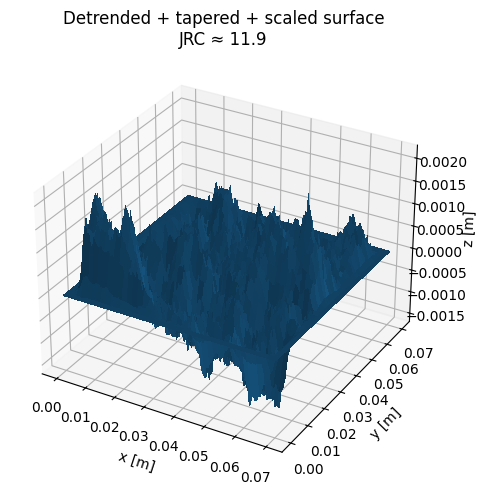

NameError: name 'vtk_before' is not defined

In [3]:
# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    out_dir = CFG["out_dir"]
    os.makedirs(out_dir, exist_ok=True)

    # Read inputs
    Lx = float(CFG["Lx"])
    Ly = float(CFG["Ly"])
    nx = int(CFG["nx"])
    ny = int(CFG["ny"])
    H = float(CFG["H"])
    JRC_target = float(CFG["JRC_target"])
    n_profiles = int(CFG["n_profiles"])
    direction = str(CFG["direction"]).lower()
    seed = CFG["seed"]
    NM = CFG["NM"]

    # NEW: boundary taper settings (add these keys to CFG)
    edge_taper_nodes = int(CFG.get("edge_taper_nodes", 0))  # 0 disables taper
    exclude_taper_in_jrc = bool(CFG.get("exclude_taper_in_jrc", True))

    # Basic validation
    if nx != ny:
        raise ValueError("For this implementation, please use nx == ny (square grid).")
    n = int(np.log2(nx - 1))
    if (2**n + 1) != nx:
        raise ValueError("nx must be 2^n + 1 (e.g., 33, 65, 129, 257, ...).")
    if direction not in ("x", "y"):
        raise ValueError("direction must be 'x' or 'y'.")

    dx = Lx / (nx - 1)
    dy = Ly / (ny - 1)

    print(f"Domain: {Lx:.3f} m x {Ly:.3f} m")
    print(f"Grid:   {nx} x {ny} (n={n})")
    print(f"dx≈{dx*1e3:.3f} mm, dy≈{dy*1e3:.3f} mm")
    print(f"H={H}, target JRC={JRC_target}, profiles={n_profiles}, direction={direction}")
    print(f"seed={seed}, NM={NM}")
    print(f"edge_taper_nodes={edge_taper_nodes} (≈{edge_taper_nodes*dx*1e3:.2f} mm)")
    print(f"exclude_taper_in_jrc={exclude_taper_in_jrc}")

    # --------------------------------------------------------
    # Helper: JRC estimate with optional exclusion of tapered margin
    # --------------------------------------------------------
    def estimate_jrc_with_optional_margin(surface, x, y, n_profiles, direction, edge_nodes, exclude_edges):
        nx, ny = surface.shape

        if direction == "x":
            # profiles are lines at fixed j (vary i)
            if exclude_edges and edge_nodes > 0:
                j_min = edge_nodes
                j_max = ny - 1 - edge_nodes
                if j_max <= j_min:
                    raise ValueError("edge_taper_nodes too large: no interior remains for JRC profiles.")
                idxs = np.linspace(j_min, j_max, n_profiles, dtype=int)
            else:
                idxs = np.linspace(0, ny - 1, n_profiles, dtype=int)

            z2_list, jrc_list = [], []
            for j in idxs:
                z_prof = surface[:, j]
                Z2 = compute_z2_profile(x, z_prof)
                z2_list.append(Z2)
                jrc_list.append(compute_jrc_from_z2(Z2))
            return float(np.mean(jrc_list)), float(np.mean(z2_list))

        else:  # direction == "y"
            # profiles are lines at fixed i (vary j)
            if exclude_edges and edge_nodes > 0:
                i_min = edge_nodes
                i_max = nx - 1 - edge_nodes
                if i_max <= i_min:
                    raise ValueError("edge_taper_nodes too large: no interior remains for JRC profiles.")
                idxs = np.linspace(i_min, i_max, n_profiles, dtype=int)
            else:
                idxs = np.linspace(0, nx - 1, n_profiles, dtype=int)

            z2_list, jrc_list = [], []
            for i in idxs:
                z_prof = surface[i, :]
                Z2 = compute_z2_profile(y, z_prof)
                z2_list.append(Z2)
                jrc_list.append(compute_jrc_from_z2(Z2))
            return float(np.mean(jrc_list)), float(np.mean(z2_list))

    # --------------------------------------------------------
    # 1) Generate surface (Liu-corrected SRA)
    # --------------------------------------------------------
    x, y, surf_raw = generate_surface_liu_corrected_sra_2d(
        n=n, Lx=Lx, Ly=Ly, H=H, sigma0=1.0, NM=NM, seed=seed
    )

    # --------------------------------------------------------
    # 2) Remove plane tilt
    # --------------------------------------------------------
    surf_detrended, (a, b, c) = detrend_plane(x, y, surf_raw)
    print("\nBest-fit plane removed (z ≈ a x + b y + c):")
    print(f"  a = dz/dx ≈ {a:.6e}  (tilt ≈ {np.degrees(np.arctan(a)):.3f} deg)")
    print(f"  b = dz/dy ≈ {b:.6e}  (tilt ≈ {np.degrees(np.arctan(b)):.3f} deg)")
    print(f"  c offset  ≈ {c:.6e}")

    # --------------------------------------------------------
    # 3) Apply edge taper to force boundary margin ~ 0
    #     (do this BEFORE scaling to target JRC)
    # --------------------------------------------------------
    surf_pre_scale = surf_detrended
    if edge_taper_nodes > 0:
        surf_pre_scale = apply_edge_taper(surf_detrended, edge_taper_nodes)

    # Export BEFORE scaling (detrended + tapered)
    vtu_before = os.path.join(out_dir, "surface_before_scaling_detrended_tapered.vtu")
    export_surface_to_vtu_unstructured(x, y, surf_pre_scale, vtu_before, scalar_name="height")
    

    # --------------------------------------------------------
    # 4) Compute mean JRC/Z2 before scaling (for reporting only)
    # --------------------------------------------------------
    jrc_mean_unscaled, z2_mean_unscaled = estimate_jrc_with_optional_margin(
        surf_pre_scale, x, y,
        n_profiles=n_profiles,
        direction=direction,
        edge_nodes=edge_taper_nodes,
        exclude_edges=exclude_taper_in_jrc
    )

    # --------------------------------------------------------
    # 5) Scale amplitude to match target JRC (profile-consistent)
    #     IMPORTANT: we use the SAME margin rule here
    # --------------------------------------------------------
    Z2_target = z2_from_target_jrc(JRC_target)
    if z2_mean_unscaled <= 0:
        raise RuntimeError("Mean Z2 (unscaled) is non-positive; cannot scale.")

    scale_factor = Z2_target / z2_mean_unscaled
    surf_scaled = surf_pre_scale * scale_factor

    jrc_mean_scaled, z2_mean_scaled = estimate_jrc_with_optional_margin(
        surf_scaled, x, y,
        n_profiles=n_profiles,
        direction=direction,
        edge_nodes=edge_taper_nodes,
        exclude_edges=exclude_taper_in_jrc
    )

    print("\nJRC calibration (renamed clearly):")
    print(f"  mean Z2 (unscaled) : {z2_mean_unscaled:.6e}")
    print(f"  mean Z2 (scaled)   : {z2_mean_scaled:.6e}")
    print(f"  mean JRC (unscaled): {jrc_mean_unscaled:.4f}")
    print(f"  mean JRC (scaled)  : {jrc_mean_scaled:.4f}")
    print(f"  scale factor       : {scale_factor:.6e}")

    # Export AFTER scaling
    vtu_after = os.path.join(out_dir, "surface_after_scaling_detrended_tapered.vtu")
    export_surface_to_vtu_unstructured(x, y, surf_scaled, vtu_after, scalar_name="height")

    # --------------------------------------------------------
    # 6) Quick plot (after scaling)
    # --------------------------------------------------------
    X, Y = np.meshgrid(x, y, indexing="ij")
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection="3d")
    ax.plot_surface(X, Y, surf_scaled, linewidth=0, antialiased=False)
    ax.set_title(f"Detrended + tapered + scaled surface\nJRC ≈ {jrc_mean_scaled:.1f}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    plt.tight_layout()
    plt.show()

    print(f"\nVTK before scaling: {vtk_before}")
    print(f"VTK after  scaling: {vtk_after}")


In this study, the fracture mechanical aperture is decomposed as (cf.\ Xue et al., 2022; Barton and Bandis, 1982)


\begin{equation}
  b = b_0 - \Delta b_n(\sigma_n) + \Delta b_{\text{dil}},
\end{equation}


where $b_0$ is the initial mechanical aperture, $\Delta b_n(\sigma_n)$ is the normal closure induced by the effective normal stress $\sigma_n$, and $\Delta b_{\text{dil}}$ is the dilatant opening.

The normal closure is described by a Bandis--Barton-type hyperbolic law,


\begin{equation}
  \Delta b_n(\sigma_n)
  = \frac{\sigma_n}{\sigma_n + k_n \, \Delta b_m}\,\Delta b_m ,
\end{equation}


with $k_n$ the normal stiffness and $\Delta b_m$ the maximum possible closure (Barton and Bandis, 1982).

In a general case, shear-induced dilatancy is related to shear slip $u_s$ and dilation angle $\psi$ via


\begin{equation}
  \Delta b_{\text{dil}} = u_s \, \tan\psi .
\end{equation}


However, in the present numerical demo no explicit shear slip $u_s$ is applied. Instead, $\Delta b_{\text{dil}}$ is prescribed directly as a uniform dilatant increment in the third loading stage. Consequently, the mean aperture evolution is


\begin{equation}
  b_1 = b_0, \qquad
  b_2 = b_0 - \Delta b_n(\sigma_n), \qquad
  b_3 = b_0 - \Delta b_n(\sigma_n) + \Delta b_{\text{dil}} ,
\end{equation}


which is consistent with the Xue-style decomposition $b = b_0 - \Delta b_n + \Delta b_s$, with $\Delta b_s \equiv \Delta b_{\text{dil}}$ imposed rather than generated by finite shear slip.


In [4]:
# ============================================================
# 0) HELPERS: JRC (Tse–Cruden) + detrend + taper
# ============================================================

def compute_z2_profile(s: np.ndarray, z: np.ndarray) -> float:
    ds = s[1:] - s[:-1]
    dz = z[1:] - z[:-1]
    return float(np.sqrt(np.mean((dz / ds) ** 2)))

def compute_jrc_from_z2(Z2: float) -> float:
    return float(32.2 + 32.47 * np.log10(Z2))

def z2_from_target_jrc(JRC_target: float) -> float:
    return float(10 ** ((JRC_target - 32.2) / 32.47))

def detrend_plane(x: np.ndarray, y: np.ndarray, z: np.ndarray):
    X, Y = np.meshgrid(x, y, indexing="ij")
    A = np.c_[X.ravel(), Y.ravel(), np.ones(X.size)]
    coeff, *_ = np.linalg.lstsq(A, z.ravel(), rcond=None)
    a, b, c = coeff.tolist()
    plane = a * X + b * Y + c
    return z - plane, (a, b, c)

def apply_edge_taper(z: np.ndarray, n: int, p: float = 3.0) -> np.ndarray:
    """Cosine taper to ~0 over n nodes on edges."""
    nx, ny = z.shape
    n = int(max(0, min(n, (min(nx, ny) // 2) - 1)))
    if n <= 0:
        return z - np.mean(z)

    t = np.linspace(0.0, 1.0, n, endpoint=False)
    ramp = 0.5 * (1.0 - np.cos(np.pi * t))  # 0 .. <1

    wx = np.ones(nx)
    wy = np.ones(ny)
    wx[:n] = ramp
    wx[-n:] = ramp[::-1]
    wy[:n] = ramp
    wy[-n:] = ramp[::-1]

    W = (wx[:, None] * wy[None, :]) ** p
    return (z - np.mean(z)) * W

def estimate_jrc_with_optional_margin(surface, x, y, n_profiles, direction, edge_nodes, exclude_edges):
    nx, ny = surface.shape

    if direction == "x":
        if exclude_edges and edge_nodes > 0:
            j_min = edge_nodes
            j_max = ny - 1 - edge_nodes
            if j_max <= j_min:
                raise ValueError("edge_taper_nodes too large: no interior remains.")
            idxs = np.linspace(j_min, j_max, n_profiles, dtype=int)
        else:
            idxs = np.linspace(0, ny - 1, n_profiles, dtype=int)

        z2_list, jrc_list = [], []
        for j in idxs:
            Z2 = compute_z2_profile(x, surface[:, j])
            z2_list.append(Z2)
            jrc_list.append(compute_jrc_from_z2(Z2))
        return float(np.mean(jrc_list)), float(np.mean(z2_list))

    if direction == "y":
        if exclude_edges and edge_nodes > 0:
            i_min = edge_nodes
            i_max = nx - 1 - edge_nodes
            if i_max <= i_min:
                raise ValueError("edge_taper_nodes too large: no interior remains.")
            idxs = np.linspace(i_min, i_max, n_profiles, dtype=int)
        else:
            idxs = np.linspace(0, nx - 1, n_profiles, dtype=int)

        z2_list, jrc_list = [], []
        for i in idxs:
            Z2 = compute_z2_profile(y, surface[i, :])
            z2_list.append(Z2)
            jrc_list.append(compute_jrc_from_z2(Z2))
        return float(np.mean(jrc_list)), float(np.mean(z2_list))

    raise ValueError("direction must be 'x' or 'y'")

# ============================================================
# 1) LIU-CORRECTED SRA (2D) surface generation (Gaussian case)
#    Grid must be N = 2^n + 1
# ============================================================

def generate_surface_liu_corrected_sra_2d(
    n: int,
    Lx: float,
    Ly: float,
    H: float,
    sigma0: float = 1.0,
    NM: int | None = None,
    seed: int | None = None,
):
    rng = np.random.default_rng(seed)
    N = 2**n + 1
    x = np.linspace(0.0, Lx, N)
    y = np.linspace(0.0, Ly, N)
    z = np.zeros((N, N), dtype=float)

    if NM is None:
        NM = n + 8

    two2H = 2.0 ** (2.0 * H)
    sigma2 = [0.0] * (NM + 1)
    sigma2[0] = sigma0**2
    sigma2[1] = sigma2[0] / two2H * (1.0 - two2H / 4.0)
    for i in range(2, NM + 1):
        sigma2[i] = sigma2[i - 1] / two2H

    # corners
    corner_std = np.sqrt(sigma2[0] / 2.0)
    z[0, 0] += rng.normal(0.0, corner_std)
    z[0, -1] += rng.normal(0.0, corner_std)
    z[-1, 0] += rng.normal(0.0, corner_std)
    z[-1, -1] += rng.normal(0.0, corner_std)

    active = np.zeros((N, N), dtype=bool)
    active[0, 0] = active[0, -1] = active[-1, 0] = active[-1, -1] = True

    step = N - 1
    for level in range(1, n + 1):
        half = step // 2

        for i in range(0, N - 1, step):
            for j in range(0, N - 1, step):
                i0, j0 = i, j
                i1, j1 = i + step, j + step
                ic, jc = i + half, j + half

                z[ic, jc] = 0.25 * (z[i0, j0] + z[i1, j0] + z[i0, j1] + z[i1, j1])

                z[ic, j0] = 0.5 * (z[i0, j0] + z[i1, j0])
                z[ic, j1] = 0.5 * (z[i0, j1] + z[i1, j1])
                z[i0, jc] = 0.5 * (z[i0, j0] + z[i0, j1])
                z[i1, jc] = 0.5 * (z[i1, j0] + z[i1, j1])

                active[ic, jc] = True
                active[ic, j0] = True
                active[ic, j1] = True
                active[i0, jc] = True
                active[i1, jc] = True

        std = np.sqrt(sigma2[level] / 2.0)
        z[active] += rng.normal(0.0, std, size=np.count_nonzero(active))
        step = half

    # correction steps
    for level in range(n + 1, NM + 1):
        std = np.sqrt(sigma2[level] / 2.0)
        z += rng.normal(0.0, std, size=z.shape)

    z -= np.mean(z)
    return x, y, z

# ============================================================
# 2) VTK export for 2D structured grid surface
# ============================================================

def export_surface_to_vtk_structured(x, y, surface, filename, scalar_name="height"):
    nx, ny = surface.shape
    grid = vtk.vtkStructuredGrid()
    grid.SetDimensions(nx, ny, 1)

    points = vtk.vtkPoints()
    points.SetNumberOfPoints(nx * ny)

    values = vtk.vtkDoubleArray()
    values.SetName(scalar_name)
    values.SetNumberOfValues(nx * ny)

    pid = 0
    for i in range(nx):
        for j in range(ny):
            points.SetPoint(pid, float(x[i]), float(y[j]), float(surface[i, j]))
            values.SetValue(pid, float(surface[i, j]))
            pid += 1

    grid.SetPoints(points)
    grid.GetPointData().SetScalars(values)

    writer = vtk.vtkStructuredGridWriter()
    writer.SetFileName(filename)
    writer.SetInputData(grid)
    writer.Write()
    print(f"VTK written: {filename}")

# ============================================================
# 3) MECHANICS: closure + dilation (your demo law)
# ============================================================

def normal_closure_hyperbolic(sigma_n, k_n, delta_bm):
    return (sigma_n / (sigma_n + k_n * delta_bm)) * delta_bm

def dilation_from_slip(u_s, psi_deg):
    psi_rad = np.deg2rad(psi_deg)
    return u_s * np.tan(psi_rad)

def compute_aperture_stages(b0, delta_bm, k_n, sigma_n, u_s, psi_deg):
    b1 = b0
    # optional: treat tension as zero closure
    if sigma_n <= 0.0:
        delta_bn = 0.0
    else:
        delta_bn = normal_closure_hyperbolic(sigma_n, k_n, delta_bm)
    b2 = b0 - delta_bn
    delta_bdil = dilation_from_slip(u_s, psi_deg)
    b3 = b2 + delta_bdil

    # safety: do not allow negative mean aperture
    b2 = max(b2, 0.0)
    b3 = max(b3, 0.0)

    return {"step1": b1, "step2": b2, "step3": b3, "delta_bn": delta_bn, "delta_bdil": delta_bdil}

def build_surfaces_mated(surf_rough, apertures):
    lower = surf_rough
    upper_surfaces = {
        "step1": surf_rough + apertures["step1"],
        "step2": surf_rough + apertures["step2"],
        "step3": surf_rough + apertures["step3"],
    }
    return lower, upper_surfaces

def export_final_surfaces_to_vtk(x, y, lower, upper_surfaces, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    export_surface_to_vtk_structured(x, y, lower, os.path.join(out_dir, "lower_surface.vtk"), "z_lower")
    export_surface_to_vtk_structured(x, y, upper_surfaces["step3"], os.path.join(out_dir, "upper_final.vtk"), "z_upper_final")

def export_lower_with_width_to_vtk(x, y, lower, upper_surfaces, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    nx, ny = lower.shape
    width_field = upper_surfaces["step3"] - lower  # point-wise aperture

    grid = vtk.vtkStructuredGrid()
    grid.SetDimensions(nx, ny, 1)

    points = vtk.vtkPoints()
    points.SetNumberOfPoints(nx * ny)

    width_arr = vtk.vtkDoubleArray()
    width_arr.SetName("width")
    width_arr.SetNumberOfValues(nx * ny)

    pid = 0
    for i in range(nx):
        for j in range(ny):
            points.SetPoint(pid, float(x[i]), float(y[j]), float(lower[i, j]))
            width_arr.SetValue(pid, float(width_field[i, j]))
            pid += 1

    grid.SetPoints(points)
    grid.GetPointData().AddArray(width_arr)
    grid.GetPointData().SetActiveScalars("width")

    writer = vtk.vtkStructuredGridWriter()
    writer.SetFileName(os.path.join(out_dir, "lower_with_width.vtk"))
    writer.SetInputData(grid)
    writer.Write()
    print("VTK written: lower_with_width.vtk (width projected on lower)")

def plot_final_surfaces_3d(lower, upper_surfaces, x, y, figsize=(10, 8)):
    X, Y = np.meshgrid(x, y, indexing="ij")
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, lower, alpha=0.8, linewidth=0, antialiased=True)
    ax.plot_surface(X, Y, upper_surfaces["step3"], alpha=0.6, linewidth=0, antialiased=True)
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title("Final fracture geometry: lower + upper (step 3)")
    plt.tight_layout()
    plt.show()

def plot_cross_sections_three_stages(lower, upper_surfaces, x, y, VE=20.0, figsize=(10, 10)):
    nx, ny = lower.shape
    j_mid = ny // 2
    x_line = x
    z_low_y_true = lower[:, j_mid]

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    stage_list = [
        ("Step 1: mated, aperture b₀",               upper_surfaces["step1"]),
        ("Step 2: + normal stress σₙ (closure)",     upper_surfaces["step2"]),
        ("Step 3: + imposed dilation Δb_dil",        upper_surfaces["step3"]),
    ]

    all_z_plot = []
    for _, upper_surf in stage_list:
        z_up_y_true = upper_surf[:, j_mid]
        a_true = z_up_y_true - z_low_y_true
        all_z_plot.append(z_low_y_true)
        all_z_plot.append(z_low_y_true + VE * a_true)

    z_min = min(z.min() for z in all_z_plot)
    z_max = max(z.max() for z in all_z_plot)
    pad = 0.05 * (z_max - z_min)

    for row, (title, upper_surf) in enumerate(stage_list):
        ax = axes[row]
        z_up_y_true = upper_surf[:, j_mid]
        a_true = z_up_y_true - z_low_y_true
        mean_a = np.mean(a_true)
        max_a = np.max(a_true)

        z_low_plot = z_low_y_true
        z_up_plot = z_low_y_true + VE * a_true

        ax.plot(x_line, z_low_plot, label="Lower surface")
        ax.plot(x_line, z_up_plot, label="Upper surface (gap ×VE)")
        ax.fill_between(x_line, z_low_plot, z_up_plot, alpha=0.3, label="Aperture (×VE)")

        ax.set_title(title, fontsize=12, pad=8)
        ax.text(
            0.5, 0.93,
            f"Mean b = {mean_a*1e3:.3f} mm, Max b = {max_a*1e3:.3f} mm",
            transform=ax.transAxes, ha="center", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
        )
        ax.set_ylim(z_min - pad, z_max + pad)
        ax.set_ylabel(f"Elevation (m)\n(aperture × {VE:.0f})")
        ax.grid(True, linestyle="--", alpha=0.4)
        if row == 0:
            ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("X (m)")
    fig.suptitle(
        "Fracture evolution: initial → closure → dilation (Y cross-section)\n"
        "(faces at top/bottom of magnified gap)",
        fontsize=16, fontweight="bold", y=0.99,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



# ============================================================
# 4) Cube builder (conformal embedding) + mapping "width"
# ============================================================

def make_stretched_z_coords(cube_height: float, n_layers: int, stretch_exponent: float = 1.0) -> np.ndarray:
    z_half = cube_height / 2.0
    s = np.linspace(0.0, 1.0, n_layers + 1)
    s_stretched = s**stretch_exponent
    z_pos = z_half * s_stretched
    z_neg = -z_pos[1:][::-1]
    return np.concatenate([z_neg, z_pos])

def _point2d_to_cell2d_avg4(point2d: np.ndarray) -> np.ndarray:
    """
    Convert point field [nx, ny] -> cell field [nx-1, ny-1] by averaging 4 corners.
    """
    return 0.25 * (
        point2d[:-1, :-1] + point2d[1:, :-1] + point2d[1:, 1:] + point2d[:-1, 1:]
    )

def create_conformal_cube_with_embedded_fracture(
    surface_vtk_file: str,
    cube_height: float,
    n_layers: int,
    stretch_exponent: float,
    out_dir: str,
    out_basename: str = "cube",
):
    print(f"🧊 Creating conformal cube from surface: {surface_vtk_file}")
    if not os.path.exists(surface_vtk_file):
        raise FileNotFoundError(f"Surface VTK file not found: {surface_vtk_file}")
    os.makedirs(out_dir, exist_ok=True)

    surface_mesh = pv.read(surface_vtk_file)
    print(f"Loaded surface mesh: {surface_mesh.n_points} points, {surface_mesh.n_cells} cells")

    pts = surface_mesh.points
    x_unique = np.unique(pts[:, 0])
    y_unique = np.unique(pts[:, 1])
    nx = len(x_unique)
    ny = len(y_unique)
    base_points = nx * ny
    n_points = surface_mesh.n_points
    if n_points % base_points != 0:
        raise ValueError("Input surface is not a regular multi-layer grid (nx*ny*k).")

    nz_layers = n_points // base_points
    print(f"Inferred grid: nx={nx}, ny={ny}, point-layers={nz_layers}")

    # Sort points by (x,y,z) so reshape works
    sort_idx = np.lexsort((pts[:, 2], pts[:, 1], pts[:, 0]))
    z_sorted = pts[sort_idx, 2]
    z_layers = z_sorted.reshape(nx, ny, nz_layers)
    z_eff = np.mean(z_layers, axis=2)

    # -------------------------
    # Build fracture cell fields
    # Priority:
    # 1) existing surface_mesh.cell_data (if valid)
    # 2) fallback: surface_mesh.point_data -> cell_data via avg4 (e.g., "width")
    # -------------------------
    fracture_cell_2d: dict[str, np.ndarray] = {}
    n_quads = (nx - 1) * (ny - 1)

    # Try cell_data first (rare for your lower_with_width.vtk)
    cells_per_layer = (nx - 1) * (ny - 1)
    if surface_mesh.n_cells % cells_per_layer == 0 and len(surface_mesh.cell_data.keys()) > 0:
        n_cell_layers = surface_mesh.n_cells // cells_per_layer
        for name in surface_mesh.cell_data.keys():
            data = np.array(surface_mesh.cell_data[name])
            if data.ndim == 1:
                arr_layers = data.reshape(n_cell_layers, ny - 1, nx - 1)
                fracture_cell_2d[name] = np.mean(arr_layers, axis=0)
            elif data.ndim == 2:
                n_comp = data.shape[1]
                arr_layers = data.reshape(n_cell_layers, ny - 1, nx - 1, n_comp)
                fracture_cell_2d[name] = np.mean(arr_layers, axis=0)
        print(f"Mapped existing cell_data fields: {list(fracture_cell_2d.keys())}")

    # Fallback: point_data -> cell_data (this is what you need for "width")
    if len(fracture_cell_2d) == 0 and len(surface_mesh.point_data.keys()) > 0:
        # Rebuild consistent point ordering array indices
        # We will reshape point_data the same way as z_layers, using sort_idx
        for name in surface_mesh.point_data.keys():
            pdata = np.array(surface_mesh.point_data[name])[sort_idx]
            if pdata.ndim == 1:
                pdata_layers = pdata.reshape(nx, ny, nz_layers)
                p2d = np.mean(pdata_layers, axis=2)  # [nx, ny]
                c2d = _point2d_to_cell2d_avg4(p2d)   # [nx-1, ny-1]
                fracture_cell_2d[name] = c2d
            elif pdata.ndim == 2:
                n_comp = pdata.shape[1]
                pdata_layers = pdata.reshape(nx, ny, nz_layers, n_comp)
                p2d = np.mean(pdata_layers, axis=2)     # [nx, ny, n_comp]
                c2d = 0.25 * (
                    p2d[:-1, :-1, :] + p2d[1:, :-1, :] + p2d[1:, 1:, :] + p2d[:-1, 1:, :]
                )  # [nx-1, ny-1, n_comp]
                fracture_cell_2d[name] = c2d
        print(f"Mapped point_data->cell_data fields: {list(fracture_cell_2d.keys())}")

    # -------------------------
    # Build 3D structured grid
    # -------------------------
    nz = 2 * n_layers + 1
    z_coords = make_stretched_z_coords(cube_height, n_layers, stretch_exponent)

    x_coords = np.linspace(x_unique.min(), x_unique.max(), nx)
    y_coords = np.linspace(y_unique.min(), y_unique.max(), ny)
    xx, yy, zz = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")

    fracture_layer = nz // 2
    fracture_z_level = z_coords[fracture_layer]
    deformation = z_eff - np.mean(z_eff)

    zz[:, :, fracture_layer] = fracture_z_level + deformation
    for k in range(fracture_layer + 1, nz):
        blend = (k - fracture_layer) / (nz - 1 - fracture_layer)
        zz[:, :, k] = z_coords[k] + deformation * (1.0 - blend)
    # bottom half left flat

    volume_mesh = pv.StructuredGrid(xx, yy, zz)

    # MaterialID on 3D cells
    n_cells_per_layer = (nx - 1) * (ny - 1)
    n_cells_3d = volume_mesh.n_cells
    assert n_cells_3d == n_cells_per_layer * (nz - 1)

    material_ids_3d = np.empty(n_cells_3d, dtype=int)
    for k in range(nz - 1):
        start = k * n_cells_per_layer
        end = start + n_cells_per_layer
        material_ids_3d[start:end] = 1 if k < fracture_layer else 2
    volume_mesh.cell_data["MaterialID"] = material_ids_3d

    # Convert to unstructured hex
    hex_ugrid = volume_mesh.cast_to_unstructured_grid()
    points = hex_ugrid.points.copy()
    cells_hex = hex_ugrid.cells.copy()
    celltypes_hex = hex_ugrid.celltypes.copy()
    n_hex_cells = hex_ugrid.n_cells

    # Build fracture quads on the middle layer (shared nodes)
    quad_cells_list = []
    for j in range(ny - 1):
        for i in range(nx - 1):
            p0 = i + nx * (j + ny * fracture_layer)
            p1 = (i + 1) + nx * (j + ny * fracture_layer)
            p2 = (i + 1) + nx * ((j + 1) + ny * fracture_layer)
            p3 = i + nx * ((j + 1) + ny * fracture_layer)
            quad_cells_list.extend([4, p0, p1, p2, p3])

    cells_quads = np.array(quad_cells_list, dtype=cells_hex.dtype)
    celltypes_quads = np.full(n_quads, pv.CellType.QUAD, dtype=celltypes_hex.dtype)

    # Combine
    cells_combined = np.concatenate([cells_hex, cells_quads])
    celltypes_combined = np.concatenate([celltypes_hex, celltypes_quads])
    combined_mesh = pv.UnstructuredGrid(cells_combined, celltypes_combined, points)

    # MaterialID for all cells
    mat_frac = np.full(n_quads, 3, dtype=int)
    combined_mesh.cell_data["MaterialID"] = np.concatenate([material_ids_3d, mat_frac])

    # Map fracture fields to combined mesh CELL DATA (zeros in bulk, values in fracture)
    n_cells_combined = combined_mesh.n_cells
    for name, cell2d in fracture_cell_2d.items():
        if cell2d.ndim == 2:
            frac_vals = cell2d.reshape(n_quads, order="C")
            all_vals = np.zeros(n_cells_combined, dtype=float)
            all_vals[n_hex_cells:] = frac_vals
            combined_mesh.cell_data[name] = all_vals
        elif cell2d.ndim == 3:
            n_comp = cell2d.shape[2]
            frac_vals = cell2d.reshape(n_quads, n_comp, order="C")
            all_vals = np.zeros((n_cells_combined, n_comp), dtype=float)
            all_vals[n_hex_cells:, :] = frac_vals
            combined_mesh.cell_data[name] = all_vals

    # Save outputs
    cube_struct_file = os.path.join(out_dir, f"{out_basename}_cube_structured.vtk")
    combined_file = os.path.join(out_dir, f"{out_basename}_cube_with_fracture_unstructured.vtu")

    volume_mesh.save(cube_struct_file)
    combined_mesh.save(combined_file)

    print(f"💾 Saved:\n  - {cube_struct_file}\n  - {combined_file}")
    print(f"Unstructured combined: points={combined_mesh.n_points}, cells={combined_mesh.n_cells}")

    return volume_mesh, combined_mesh



def run_all_from_cfg(CFG):
    required = [
        "Lx","Ly","nx","ny","H","JRC_target","n_profiles","direction","seed","NM",
        "out_dir","edge_taper_nodes","exclude_taper_in_jrc",
        "b0","delta_bm","k_n","sigma_n","u_s","psi_deg","VE",
        "out_dir","cube_height","n_layers","stretch_exponent",
    ]
    missing = [k for k in required if k not in CFG]
    if missing:
        raise KeyError(f"CFG is missing keys: {missing}")

    Lx = float(CFG["Lx"]); Ly = float(CFG["Ly"])
    nx = int(CFG["nx"]); ny = int(CFG["ny"])
    if nx != ny:
        raise ValueError("Please use nx == ny for this implementation.")
    n = int(np.log2(nx - 1))
    if (2**n + 1) != nx:
        raise ValueError("nx must be 2^n + 1 (e.g., 33, 65, 129, 257, ...).")

    H = float(CFG["H"])
    JRC_target = float(CFG["JRC_target"])
    n_profiles = int(CFG["n_profiles"])
    direction = str(CFG["direction"]).lower()
    seed = CFG["seed"]
    NM = CFG["NM"]

    out_dir = str(CFG["out_dir"])
    os.makedirs(out_dir, exist_ok=True)

    edge_taper_nodes = int(CFG["edge_taper_nodes"])
    exclude_taper_in_jrc = bool(CFG["exclude_taper_in_jrc"])

    print(f"Domain: {Lx:.3f} m x {Ly:.3f} m | Grid: {nx}x{ny} | H={H} | target JRC={JRC_target}")

    # (A) Generate surface
    x, y, surf_raw = generate_surface_liu_corrected_sra_2d(n=n, Lx=Lx, Ly=Ly, H=H, sigma0=1.0, NM=NM, seed=seed)
    surf_detrended, (a, b, c) = detrend_plane(x, y, surf_raw)
    print(f"Detrended plane: a={a:.3e}, b={b:.3e}, c={c:.3e}")

    surf_pre_scale = surf_detrended
    if edge_taper_nodes > 0:
        surf_pre_scale = apply_edge_taper(surf_pre_scale, edge_taper_nodes)

    # (B) Scale to target JRC
    jrc_unscaled, z2_unscaled = estimate_jrc_with_optional_margin(
        surf_pre_scale, x, y, n_profiles, direction, edge_taper_nodes, exclude_taper_in_jrc
    )
    Z2_target = z2_from_target_jrc(JRC_target)
    if z2_unscaled <= 0.0:
        raise RuntimeError("Mean Z2 (unscaled) is non-positive; cannot scale.")
    scale_factor = Z2_target / z2_unscaled
    surf_scaled = surf_pre_scale * scale_factor
    jrc_scaled, z2_scaled = estimate_jrc_with_optional_margin(
        surf_scaled, x, y, n_profiles, direction, edge_taper_nodes, exclude_taper_in_jrc
    )
    print(f"JRC: unscaled≈{jrc_unscaled:.2f} -> scaled≈{jrc_scaled:.2f} | scale_factor={scale_factor:.3e}")

    export_surface_to_vtk_structured(x, y, surf_scaled, os.path.join(out_dir, "surface_scaled.vtk"), "height")

    # (C) Mechanics + VTK exports + plots
    out_dir = str(CFG["out_dir"])
    os.makedirs(out_dir, exist_ok=True)

    b0 = float(CFG["b0"])
    delta_bm = float(CFG["delta_bm"])
    k_n = float(CFG["k_n"])
    sigma_n = float(CFG["sigma_n"])
    u_s = float(CFG["u_s"])
    psi_deg = float(CFG["psi_deg"])
    VE = float(CFG["VE"])

    apertures = compute_aperture_stages(b0, delta_bm, k_n, sigma_n, u_s, psi_deg)
    print("Mean mechanical apertures:")
    print(f"  Step 1: b1 = {apertures['step1']*1e3:.3f} mm")
    print(f"  Step 2: b2 = {apertures['step2']*1e3:.3f} mm")
    print(f"  Step 3: b3 = {apertures['step3']*1e3:.3f} mm")
    print(f"  Δb_n   = {apertures['delta_bn']*1e3:.3f} mm")
    print(f"  Δb_dil = {apertures['delta_bdil']*1e3:.3f} mm")

    lower, upper_surfaces = build_surfaces_mated(surf_scaled, apertures)
    export_final_surfaces_to_vtk(x, y, lower, upper_surfaces, out_dir)
    export_lower_with_width_to_vtk(x, y, lower, upper_surfaces, out_dir)

    plot_final_surfaces_3d(lower, upper_surfaces, x, y)
    plot_cross_sections_three_stages(lower, upper_surfaces, x, y, VE=VE)

    # (D) Cube + embedded fracture
    cube_height = float(CFG["cube_height"])
    n_layers = int(CFG["n_layers"])
    stretch_exponent = float(CFG["stretch_exponent"])

    surface_vtk_path = os.path.join(out_dir, "lower_with_width.vtk")
    volume_mesh, combined_mesh = create_conformal_cube_with_embedded_fracture(
        surface_vtk_file=surface_vtk_path,
        cube_height=cube_height,
        n_layers=n_layers,
        stretch_exponent=stretch_exponent,
        out_dir=out_dir,
        out_basename="lower_with_width",
    )

    return surf_scaled, x, y, volume_mesh, combined_mesh



Domain: 0.070 m x 0.070 m | Grid: 129x129 | H=0.8 | target JRC=12.0
Detrended plane: a=1.764e+01, b=-6.557e+00, c=-3.880e-01
JRC: unscaled≈80.85 -> scaled≈11.94 | scale_factor=7.545e-03
VTK written: _out_xue_closure/surface_scaled.vtk
Mean mechanical apertures:
  Step 1: b1 = 1.000 mm
  Step 2: b2 = 0.206 mm
  Step 3: b3 = 0.306 mm
  Δb_n   = 0.794 mm
  Δb_dil = 0.100 mm
VTK written: _out_xue_closure/lower_surface.vtk
VTK written: _out_xue_closure/upper_final.vtk
VTK written: lower_with_width.vtk (width projected on lower)


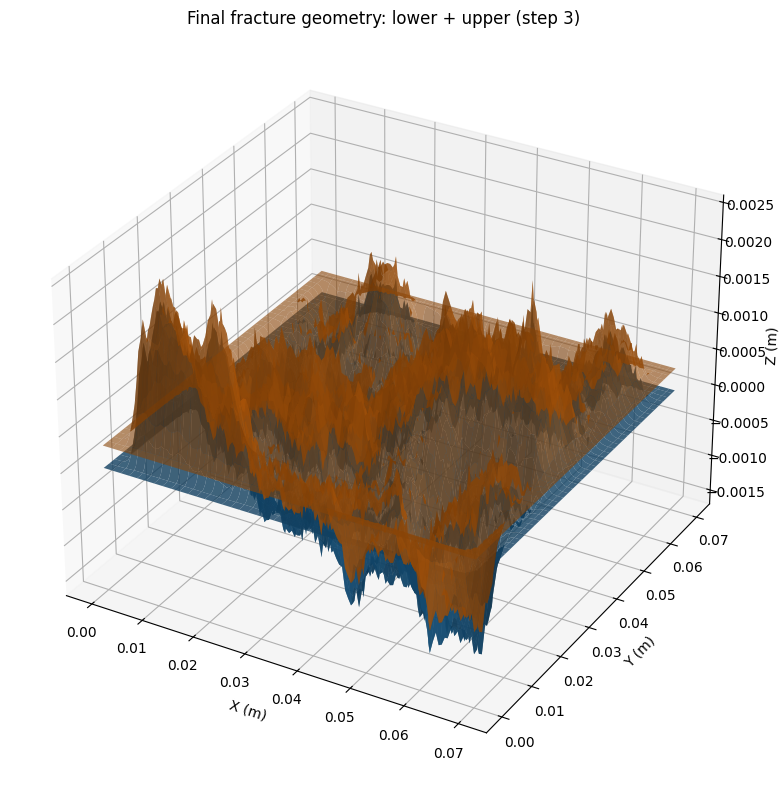

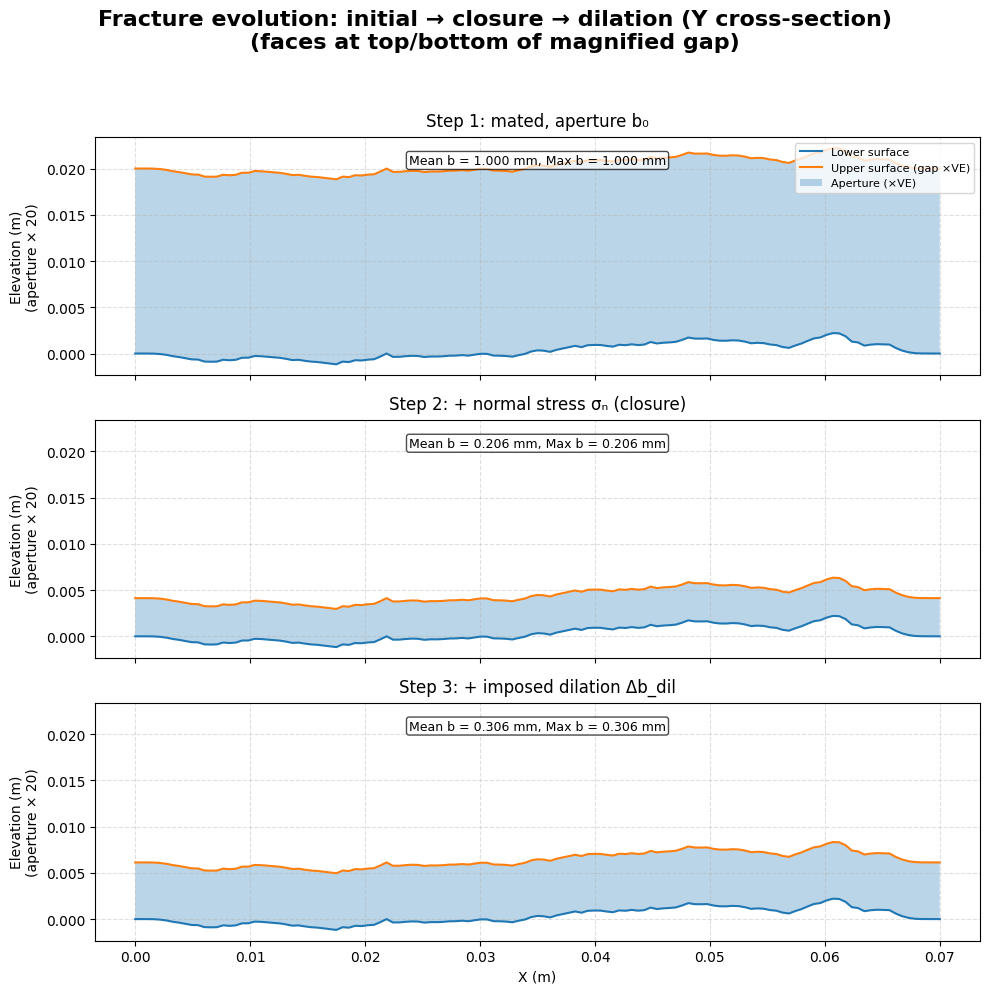

🧊 Creating conformal cube from surface: _out_xue_closure/lower_with_width.vtk
Loaded surface mesh: 16641 points, 16384 cells
Inferred grid: nx=129, ny=129, point-layers=1
Mapped point_data->cell_data fields: ['width']
💾 Saved:
  - _out_xue_closure/lower_with_width_cube_structured.vtk
  - _out_xue_closure/lower_with_width_cube_with_fracture_unstructured.vtu
Unstructured combined: points=116487, cells=114688


In [5]:
# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    surf_scaled, x, y, volume_mesh, combined_mesh = run_all_from_cfg(CFG)